# **Hands-On Exploration**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to display an image using matplotlib
def display_image(img, title="Image"):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Function to display two images side by side
def display_images(img1, img2, title1="Image 1", title2="Image 2"):
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title(title1)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.title(title2)
    plt.axis('off')

    plt.show()

Saving Juliano.png to Juliano (3).png


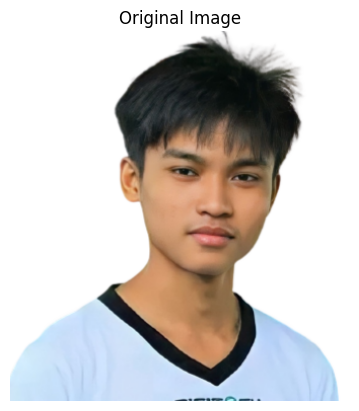

In [3]:
from google.colab import files
from io import BytesIO
from PIL import Image

# Upload an image
uploaded = files.upload()

# Convert to OpenCV format
image_path = next(iter(uploaded))  # Get the image file name
image = Image.open(BytesIO(uploaded[image_path]))
image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

display_image(image, "Original Image")

# **IMAGE TRANSFORMATIONS**

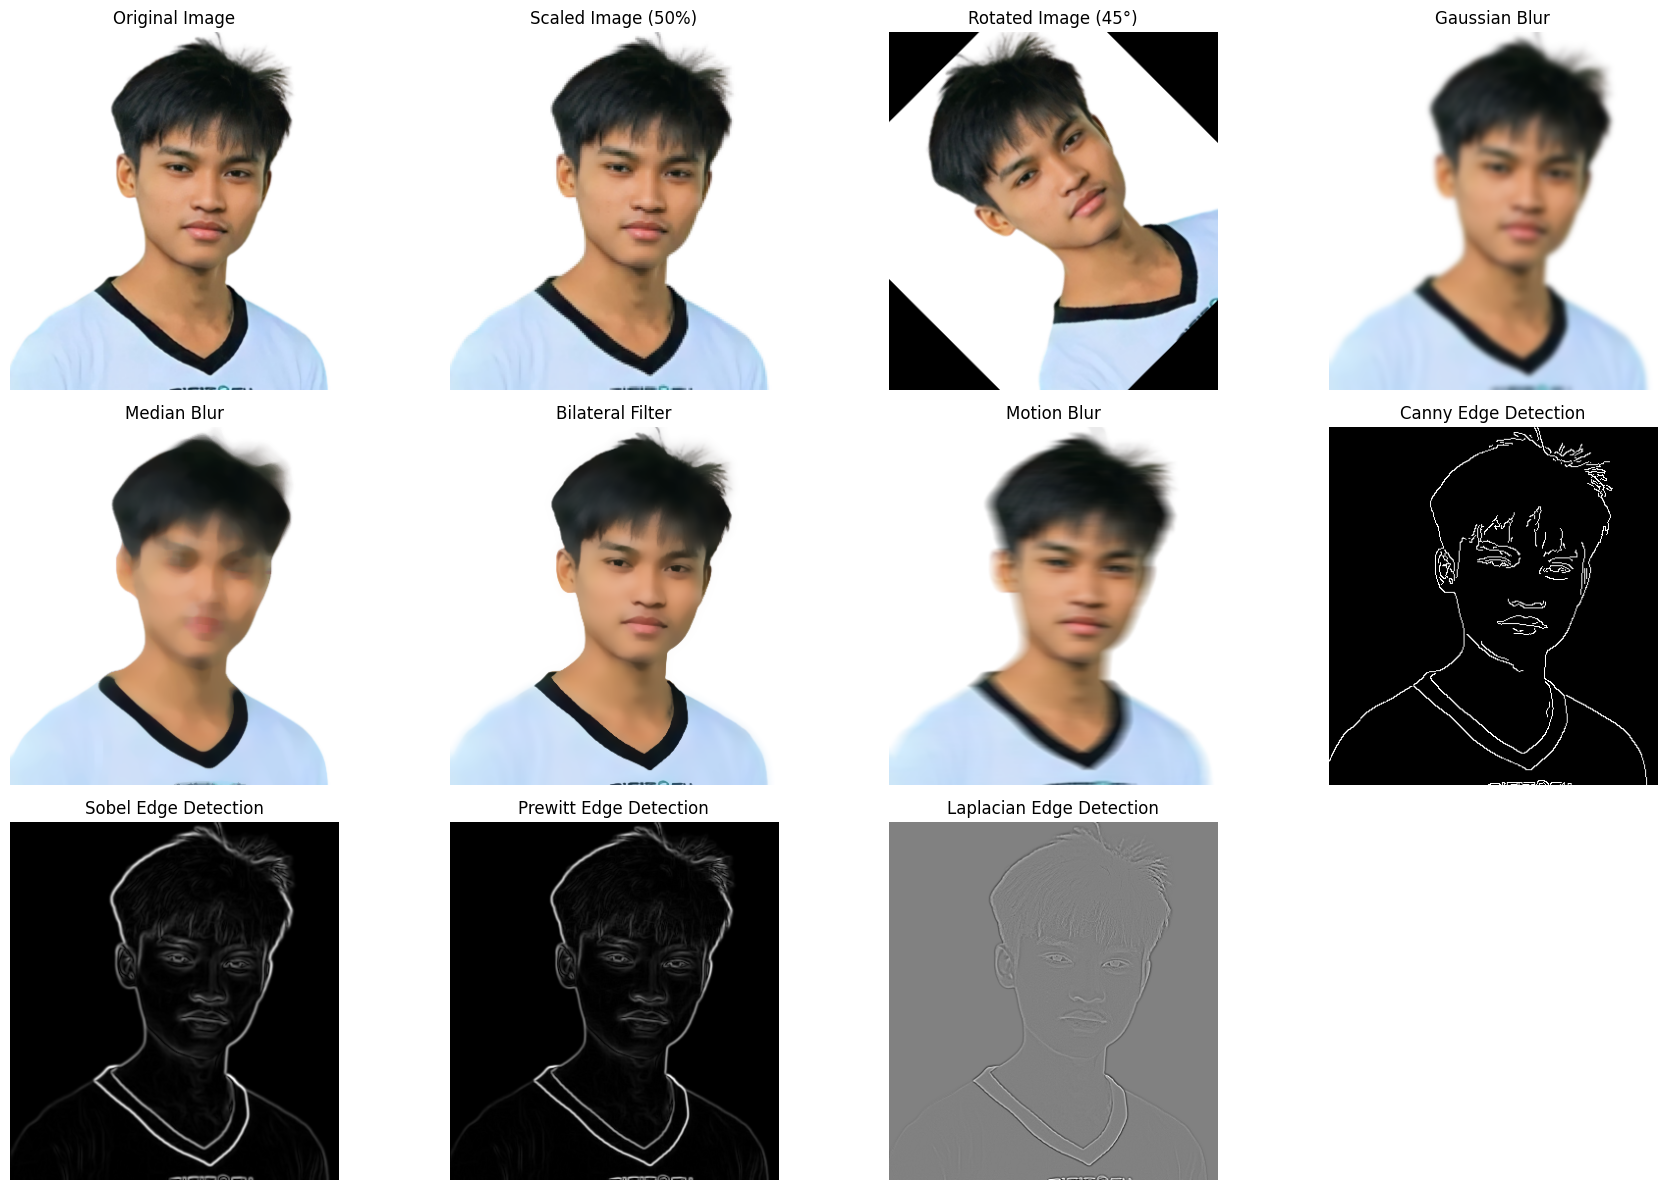

In [5]:
# Convert to OpenCV format
image_path = 'Juliano.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Scaling function
def scale_image(img, scale_factor):
    height, width = img.shape[:2]
    scaled_img = cv2.resize(img, (int(width * scale_factor), int(height * scale_factor)), interpolation=cv2.INTER_LINEAR)
    return scaled_img

# Rotate function
def rotate_image(img, angle):
    height, width = img.shape[:2]
    center = (width // 2, height // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_img = cv2.warpAffine(img, matrix, (width, height))
    return rotated_img

# Apply scaling and rotation
scaled_image = scale_image(image, 0.5)
rotated_image = rotate_image(image, 45)

# Applying Gaussian, Median, Bilateral filters, and Motion Blur
gaussian_blur = cv2.GaussianBlur(image, (15, 15), 0)
median_blur = cv2.medianBlur(image, 15)
bilateral_filter = cv2.bilateralFilter(image, 15, 75, 75)

# Motion blur function
def motion_blur(img):
    kernel_size = 15
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)
    kernel = kernel / kernel_size
    motion_blurred = cv2.filter2D(img, -1, kernel)
    return motion_blurred

# Apply Motion blur
motion_blurred = motion_blur(image)

# Applying Canny, Sobel, Prewitt, and Laplacian Edge Detection
canny_edges = cv2.Canny(image, 100, 200)

def sobel_edge_detection(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
    return cv2.magnitude(sobelx, sobely)

sobel_edges = sobel_edge_detection(image)

def prewitt_edge_detection(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernelx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=int)
    kernely = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
    prewittx = cv2.filter2D(gray, cv2.CV_64F, kernelx)
    prewitty = cv2.filter2D(gray, cv2.CV_64F, kernely)
    return cv2.magnitude(prewittx, prewitty)

prewitt_edges = prewitt_edge_detection(image)

def laplacian_edge_detection(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F)

laplacian_edges = laplacian_edge_detection(image)

# Display the results in a 3x4 grid
plt.figure(figsize=(18, 12))

# Original Image
plt.subplot(3, 4, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')

# Scaled Image
plt.subplot(3, 4, 2)
plt.imshow(scaled_image)
plt.title("Scaled Image (50%)")
plt.axis('off')

# Rotated Image
plt.subplot(3, 4, 3)
plt.imshow(rotated_image)
plt.title("Rotated Image (45°)")
plt.axis('off')

# Gaussian Blur
plt.subplot(3, 4, 4)
plt.imshow(gaussian_blur)
plt.title("Gaussian Blur")
plt.axis('off')

# Median Blur
plt.subplot(3, 4, 5)
plt.imshow(median_blur)
plt.title("Median Blur")
plt.axis('off')

# Bilateral Filter
plt.subplot(3, 4, 6)
plt.imshow(bilateral_filter)
plt.title("Bilateral Filter")
plt.axis('off')

# Motion Blur
plt.subplot(3, 4, 7)
plt.imshow(motion_blurred)
plt.title("Motion Blur")
plt.axis('off')

# Canny Edge Detection
plt.subplot(3, 4, 8)
plt.imshow(canny_edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

# Sobel Edge Detection
plt.subplot(3, 4, 9)
plt.imshow(sobel_edges, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis('off')

# Prewitt Edge Detection
plt.subplot(3, 4, 10)
plt.imshow(prewitt_edges, cmap='gray')
plt.title("Prewitt Edge Detection")
plt.axis('off')

# Laplacian Edge Detection
plt.subplot(3, 4, 11)
plt.imshow(laplacian_edges, cmap='gray')
plt.title("Laplacian Edge Detection")
plt.axis('off')

plt.tight_layout()
plt.show()